In [44]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as py


In [2]:
df = pd.read_csv('large_sales_data.csv', encoding = 'latin-1')
print("--- Initial Data Inspection (First 5 Rows) ---")
print(df.head())

--- Initial Data Inspection (First 5 Rows) ---
  Region Salesperson  Revenue  Profit  Units_Sold  Customer_Satisfaction  \
0   East       Alice   137118   10067         219                   4.06   
1   West       Alice    78577   38481         750                   2.64   
2  North       Alice    19078   28037         406                   3.62   
3   East         Eve   166075   10557         109                   2.04   
4   East       David    72768   10435          40                   1.64   

   Marketing_Spend  Discount_Percentage Product_Category Sales_Channel  \
0            14666                13.40        Furniture        Retail   
1             8254                 3.70       Automobile     Wholesale   
2            14746                 6.18        Furniture        Retail   
3             4578                 0.03        Furniture        Online   
4            13353                 1.18      Electronics     Wholesale   

   Order_Processing_Time  
0                      1

In [3]:
print("\n--- Data Types and Null Count (Cleanliness Check) ---")
print(df.info())



--- Data Types and Null Count (Cleanliness Check) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Region                 1000 non-null   object 
 1   Salesperson            1000 non-null   object 
 2   Revenue                1000 non-null   int64  
 3   Profit                 1000 non-null   int64  
 4   Units_Sold             1000 non-null   int64  
 5   Customer_Satisfaction  1000 non-null   float64
 6   Marketing_Spend        1000 non-null   int64  
 7   Discount_Percentage    1000 non-null   float64
 8   Product_Category       1000 non-null   object 
 9   Sales_Channel          1000 non-null   object 
 10  Order_Processing_Time  1000 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 86.1+ KB
None


Customer Satisfaction Scale

In [13]:

df.loc[:, 'Profit_Ratio'] = df['Profit'] / df['Revenue']

bins = [1, 2, 3, 4, 5.1]
labels = ['1.0-2.0 (Low)', '2.0-3.0 (Medium-Low)', '3.0-4.0 (Medium-High)', '4.0-5.0 (High)']

df.loc[:, 'Satisfaction_Level'] = pd.cut(
    df['Customer_Satisfaction'],
    bins=bins,
    labels=labels,
    right=False
).astype(str)


print("--- New Columns Verification ---")

--- New Columns Verification ---


In [14]:
print(df.head())


  Region Salesperson  Revenue  Profit  Units_Sold  Customer_Satisfaction  \
0   East       Alice   137118   10067         219                   4.06   
1   West       Alice    78577   38481         750                   2.64   
2  North       Alice    19078   28037         406                   3.62   
3   East         Eve   166075   10557         109                   2.04   
4   East       David    72768   10435          40                   1.64   

   Marketing_Spend  Discount_Percentage Product_Category Sales_Channel  \
0            14666                13.40        Furniture        Retail   
1             8254                 3.70       Automobile     Wholesale   
2            14746                 6.18        Furniture        Retail   
3             4578                 0.03        Furniture        Online   
4            13353                 1.18      Electronics     Wholesale   

   Order_Processing_Time     Satisfaction_Level  Profit_Ratio  
0                      1         4

Profitability by Product Category

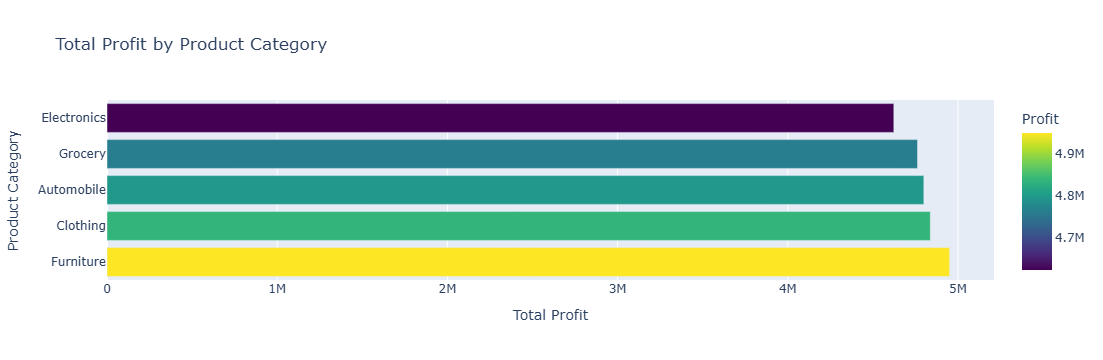

In [49]:

profit_by_category = df.groupby('Product_Category')['Profit'].sum().reset_index()
profit_by_category = profit_by_category.sort_values(by='Profit', ascending=False)

fig1 = px.bar(
    profit_by_category,
    x='Profit',
    y='Product_Category',
    orientation='h',
    title=' Total Profit by Product Category',
    color='Profit',
    color_continuous_scale=px.colors.sequential.Viridis
)
fig1.update_layout(xaxis_title='Total Profit', yaxis_title='Product Category')
fig1.show()

Discount Effectiveness Analysis

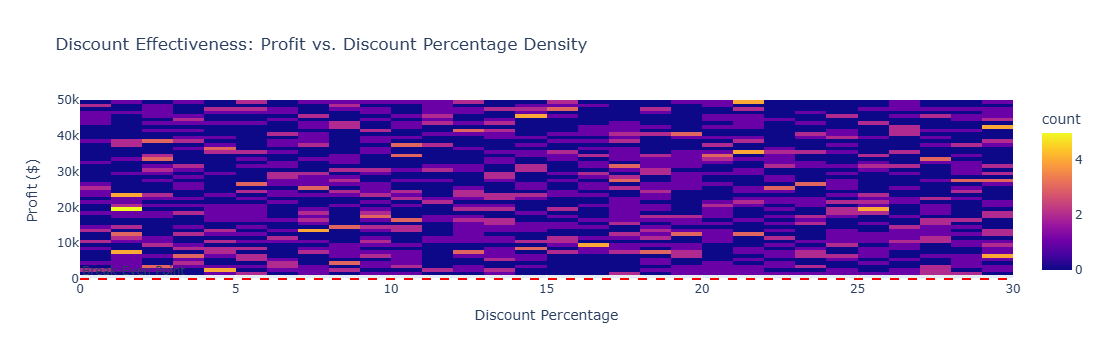

In [56]:

if 'Profit_Ratio' not in df.columns:
    df.loc[:, 'Profit_Ratio'] = df['Profit'] / df['Revenue']

fig_density = px.density_heatmap(
    df,
    x='Discount_Percentage',
    y='Profit',
    nbinsx=50,
    nbinsy=50,
    histfunc='count',
    title='Discount Effectiveness: Profit vs. Discount Percentage Density'
)

fig_density.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Break-Even Point", annotation_position="top left")

fig_density.update_layout(
    xaxis_title='Discount Percentage',
    yaxis_title='Profit ($)'
)
fig_density.show()

Profit Distribution by Customer Satisfaction Level

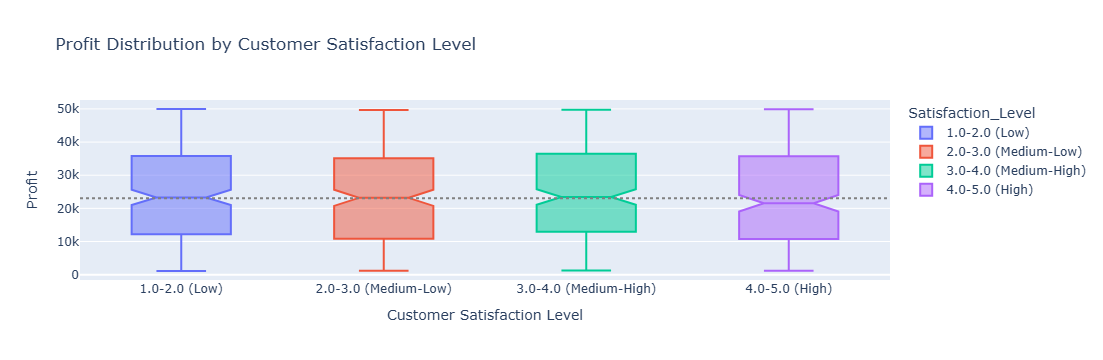

In [57]:
fig3 = px.box(
    df.sort_values(by='Satisfaction_Level'),
    x='Satisfaction_Level',
    y='Profit',
    color='Satisfaction_Level',
    title=' Profit Distribution by Customer Satisfaction Level',
    notched=True
)
fig3.add_hline(y=df['Profit'].median(), line_dash="dot", line_color="gray")
fig3.update_layout(xaxis_title='Customer Satisfaction Level', yaxis_title='Profit')
fig3.show()

Regional Revenue Breakdo

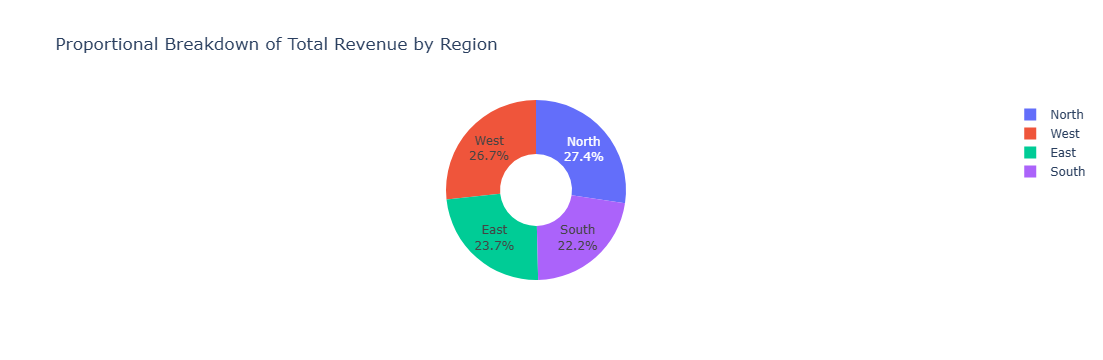

In [58]:
revenue_by_region = df.groupby('Region')['Revenue'].sum().reset_index()

fig8 = px.pie(
    revenue_by_region,
    names='Region',
    values='Revenue',
    title=' Proportional Breakdown of Total Revenue by Region',
    hole=0.4 
)
fig8.update_traces(textposition='inside', textinfo='percent+label')
fig8.show()

Revenue and Profit Grouped Comparison

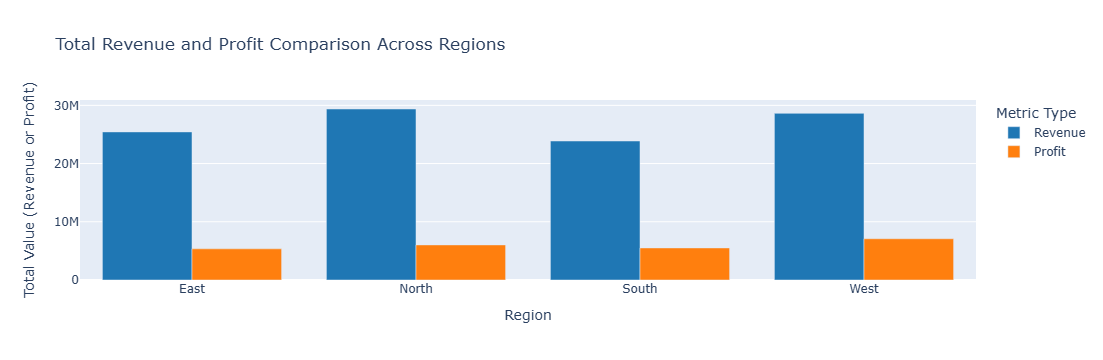

In [59]:
regional_summary = df.groupby('Region')[['Revenue', 'Profit']].sum().reset_index()

df_long = pd.melt(
    regional_summary,
    id_vars=['Region'],
    value_vars=['Revenue', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

fig_grouped = px.bar(
    df_long,
    x='Region',
    y='Value',
    color='Metric',
    barmode='group', 
    title='Total Revenue and Profit Comparison Across Regions',
    color_discrete_sequence=['#1f77b4', '#ff7f0e'] 
)

fig_grouped.update_layout(
    xaxis_title='Region',
    yaxis_title='Total Value (Revenue or Profit)',
    legend_title='Metric Type'
)
fig_grouped.show()

Profit Breakdown

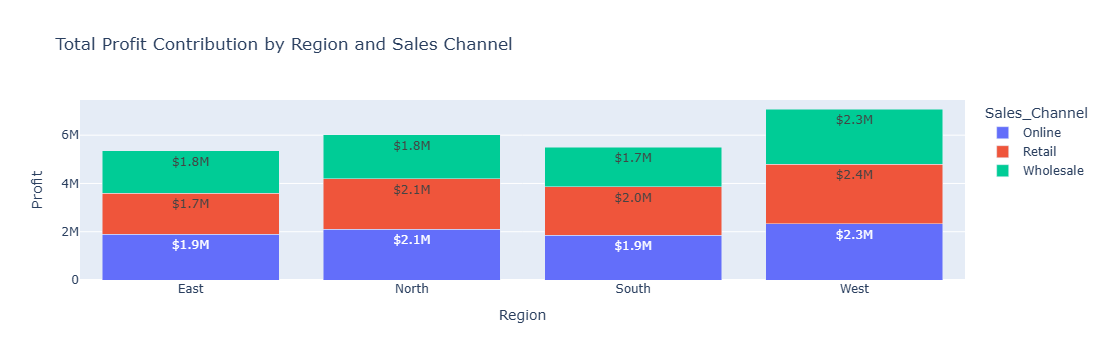

In [60]:

profit_breakdown = df.groupby(['Region', 'Sales_Channel'])['Profit'].sum().reset_index()

fig6 = px.bar(
    profit_breakdown,
    x='Region',
    y='Profit',
    color='Sales_Channel',
    title=' Total Profit Contribution by Region and Sales Channel',
    barmode='stack',
    text='Profit'
)

fig6.update_traces(texttemplate='$%{text:.2s}', textposition='inside')
fig6.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig6.show()

Average Profit Ratio Trend Across Discount Bins

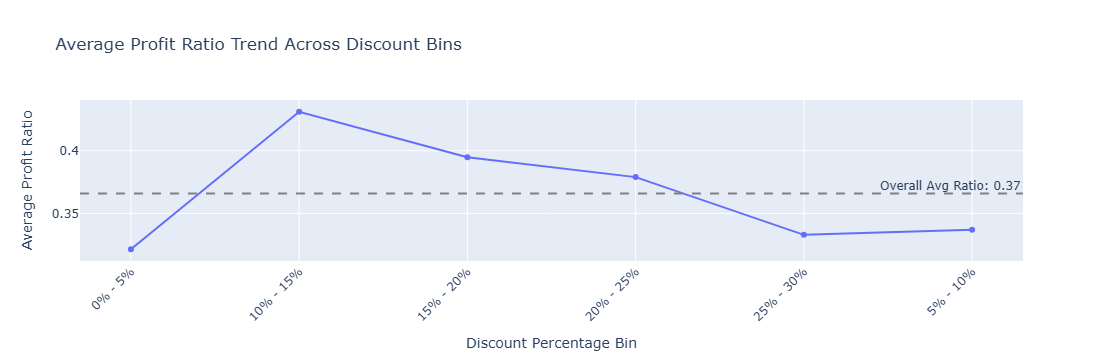

In [43]:
if 'Profit_Ratio' not in df.columns:
    df.loc[:, 'Profit_Ratio'] = df['Profit'] / df['Revenue']


max_discount = df['Discount_Percentage'].max()

bins = [i * 5 for i in range(int(max_discount / 5) + 2)]
labels = [f'{i*5}% - {(i+1)*5}%' for i in range(len(bins) - 1)]


df.loc[:, 'Discount_Bin'] = pd.cut(
    df['Discount_Percentage'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
).astype(str)


discount_trend = df.groupby('Discount_Bin', observed=False)['Profit_Ratio'].mean().reset_index()



discount_trend = df.groupby('Discount_Bin', observed=False)['Profit_Ratio'].mean().reset_index()

fig_line = px.line(
    discount_trend,
    x='Discount_Bin',
    y='Profit_Ratio',
    markers=True, # Show markers on the line
    title='Average Profit Ratio Trend Across Discount Bins',
)

# Add a horizontal line for the overall average profit ratio for reference
overall_avg_ratio = df['Profit_Ratio'].mean()
fig_line.add_hline(y=overall_avg_ratio, line_dash="dash", line_color="gray", annotation_text=f"Overall Avg Ratio: {overall_avg_ratio:.2f}", annotation_position="top right")

fig_line.update_layout(
    xaxis_title='Discount Percentage Bin',
    yaxis_title='Average Profit Ratio',
    xaxis_tickangle=-45 # Rotates labels for better readability
)
fig_line.show()

Financial Metrics

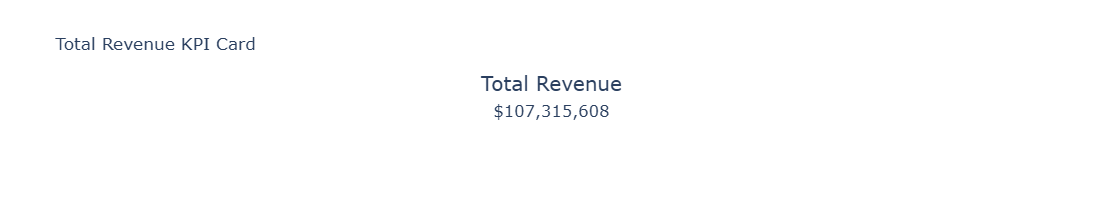

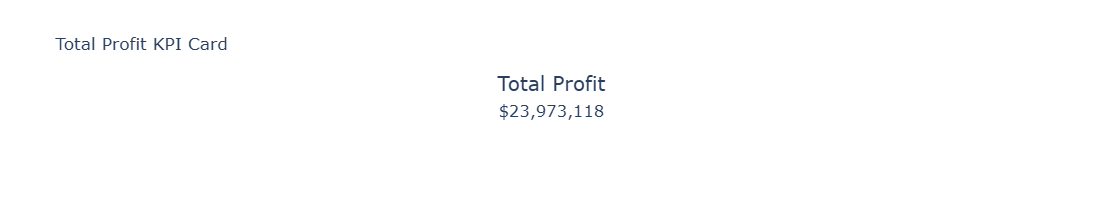

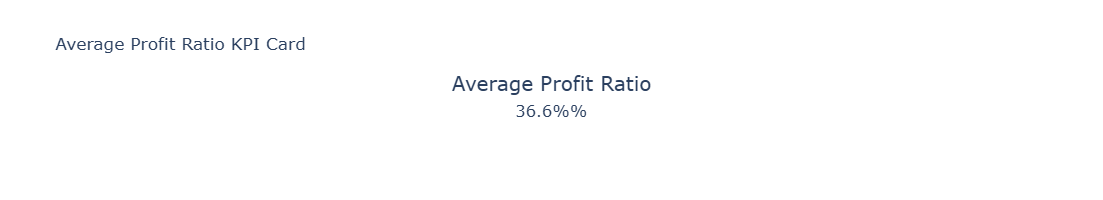

In [61]:



TOTAL_REVENUE = 107315608
TOTAL_PROFIT = 23973118
AVG_PROFIT_RATIO = 0.3658 # 36.58%


fig_rev = go.Figure(go.Indicator(
    mode = "number",
    value = TOTAL_REVENUE,
    number = {'prefix': "$", 'valueformat': ",.0f"},
    title = {"text": "Total Revenue"},
    domain = {'x': [0, 1], 'y': [0, 1]}
))
fig_rev.update_layout(title_text=' Total Revenue KPI Card', height=200)
py.iplot(fig_rev)


fig_prof = go.Figure(go.Indicator(
    mode = "number",
    value = TOTAL_PROFIT,
    number = {'prefix': "$", 'valueformat': ",.0f"},
    title = {"text": "Total Profit"},
    domain = {'x': [0, 1], 'y': [0, 1]}
))
fig_prof.update_layout(title_text=' Total Profit KPI Card', height=200)
py.iplot(fig_prof)

fig_ratio = go.Figure(go.Indicator(
    mode = "number",
    value = AVG_PROFIT_RATIO,
    number = {'suffix': "%", 'valueformat': ".1%"},
    title = {"text": "Average Profit Ratio"},
    domain = {'x': [0, 1], 'y': [0, 1]}
))
fig_ratio.update_layout(title_text='Average Profit Ratio KPI Card', height=200)
py.iplot(fig_ratio)

Revenue hierarchy

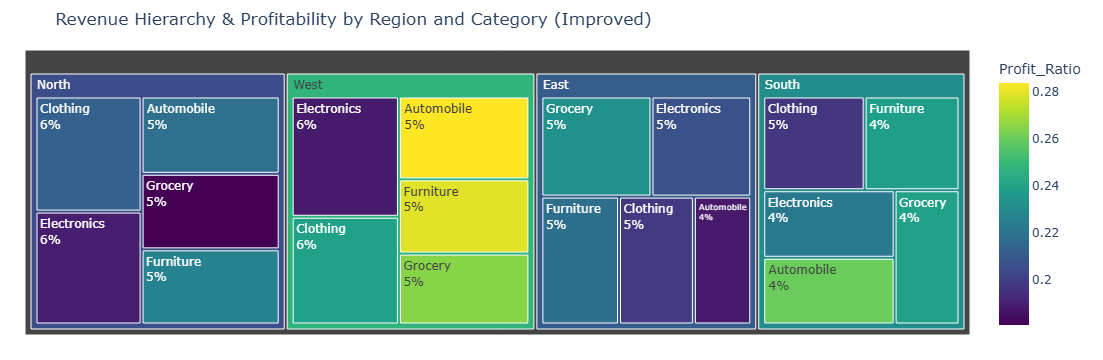

In [62]:
import plotly.express as px

fig_tree_ = px.treemap(
    df,
    path=['Region', 'Product_Category'],
    values='Revenue',
    color='Profit_Ratio',
    title=' Revenue Hierarchy & Profitability by Region and Category (Improved)',
    hover_data={'Profit': ':.2s', 'Revenue': ':.2s', 'Profit_Ratio': ':.2%'},
    color_continuous_scale='Viridis'
)

fig_tree_.update_traces(
    textinfo='label+percent entry'
)

fig_tree_.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig_tree_.show()

Customer Satisfaction

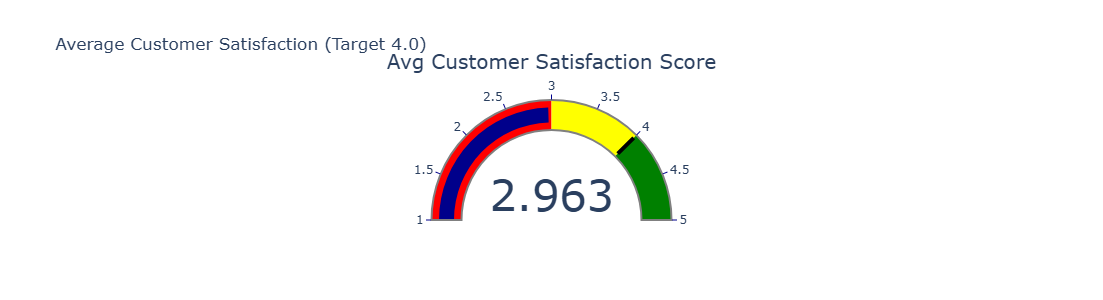

In [66]:
AVG_SATISFACTION = 2.963
TARGET_SATISFACTION = 4.0

fig_gauge = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = AVG_SATISFACTION,
    domain = {'x': [0, 1], 'y': [0, 1]},
    title = {'text': "Avg Customer Satisfaction Score"},
    gauge = {
        'shape': "angular", 
        'axis': {'range': [1, 5], 'tickwidth': 1, 'tickcolor': "darkblue"},
        'bar': {'color': "darkblue"},
        'bgcolor': "white",
        'borderwidth': 2,
        'bordercolor': "gray",
        'steps': [
           
            {'range': [1, 3], 'color': 'red'}, 
            {'range': [3, 4], 'color': 'yellow'}, 
            {'range': [4, 5], 'color': 'green'} 
        ],
        
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'thickness': 0.75,
            'value': TARGET_SATISFACTION
        }
    }
))

fig_gauge.update_layout(title_text=' Average Customer Satisfaction (Target 4.0)', height=300)

py.iplot(fig_gauge)